***Stage 1***



In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"apurba786","key":"4ed0b7fe97217df27f23fe81d7a87644"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API configured Successfully.")

Kaggle API configured Successfully.


In [3]:
!pip install -q kaggle

!kaggle competitions download \
-c aptos2019-blindness-detection

print("Dataset Downloaded Successfully.")

100% 9.51G/9.51G [01:20<00:00, 126MB/s]

Dataset Downloaded Successfully.


In [4]:
import zipfile
import os

ZIP_FILE = "aptos2019-blindness-detection.zip"
EXTRACT_PATH = "./aptos_dataset"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully.")
print(f"Dataset Location: {EXTRACT_PATH}")

Dataset extracted successfully.
Dataset Location: ./aptos_dataset


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score
)


import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print('Tensorflow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

Tensorflow version: 2.20.0
GPU Available: []


In [7]:
BASE_PATH = './aptos_dataset/'

train_df = pd.read_csv(BASE_PATH + 'train.csv')

print('Original dataset shape:', train_df.shape)
print('\nOriginal Class Distribution:')
print(train_df['diagnosis'].value_counts().sort_index())

train_df['binary_label'] = train_df['diagnosis'].apply(lambda x: 0 if x == 0 else 1)

print('\nBinary Class Distribution:')
print(train_df['binary_label'].value_counts())
print('\n0 = Normal, 1 = Diabetic Retinopathy')

train_df['image_path'] = train_df['id_code'].apply(
    lambda x: BASE_PATH + f'train_images/{x}.png'
)

train_df['binary_label'] = train_df['binary_label'].astype(str)

print('\nSample Data:')
print(train_df.head())

Original dataset shape: (3662, 2)

Original Class Distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Binary Class Distribution:
binary_label
1    1857
0    1805
Name: count, dtype: int64

0 = Normal, 1 = Diabetic Retinopathy

Sample Data:
        id_code  diagnosis binary_label  \
0  000c1434d8d7          2            1   
1  001639a390f0          4            1   
2  0024cdab0c1e          1            1   
3  002c21358ce6          0            0   
4  005b95c28852          0            0   

                                      image_path  
0  ./aptos_dataset/train_images/000c1434d8d7.png  
1  ./aptos_dataset/train_images/001639a390f0.png  
2  ./aptos_dataset/train_images/0024cdab0c1e.png  
3  ./aptos_dataset/train_images/002c21358ce6.png  
4  ./aptos_dataset/train_images/005b95c28852.png  


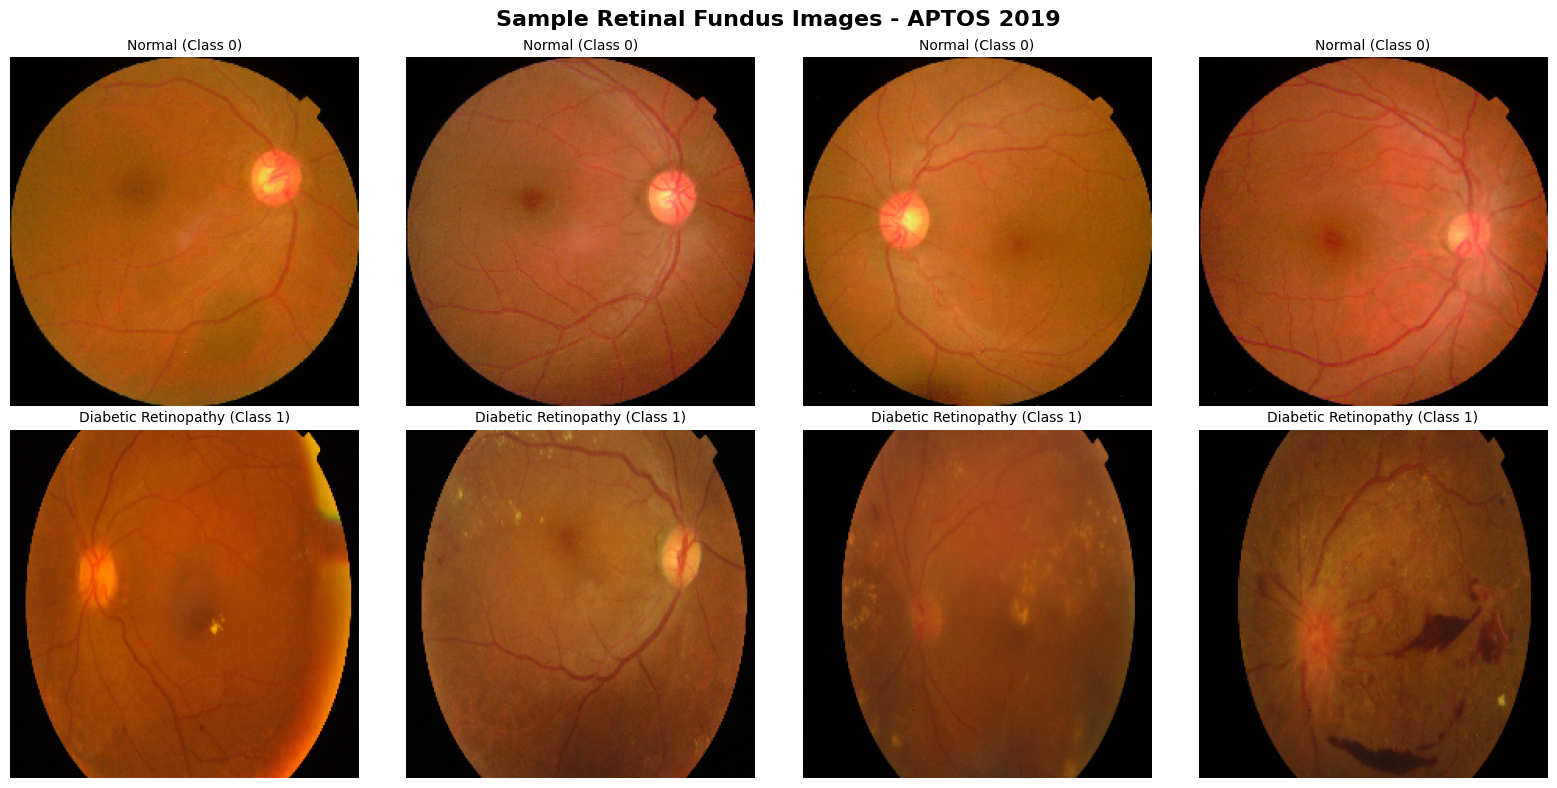

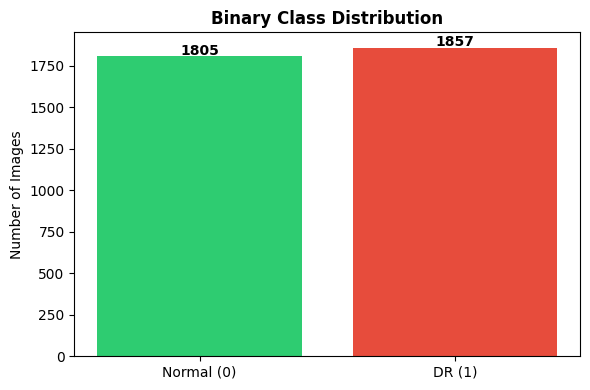

In [10]:
from tensorflow.keras.preprocessing.image import load_img

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Retinal Fundus Images - APTOS 2019', fontsize=16, fontweight='bold')

labels = ['Normal (Class 0)', 'Diabetic Retinopathy (Class 1)']

for i, label in enumerate(['0', '1']):
    samples = train_df[train_df['binary_label'] == label].sample(4)

    for j, (_, row) in enumerate(samples.iterrows()):
        img = load_img(row['image_path'], target_size=(224, 224))
        axes[i, j].imshow(img)
        axes[i, j].set_title(labels[i], fontsize=10)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
counts = train_df['binary_label'].value_counts()
ax.bar(['Normal (0)', 'DR (1)'], [counts['0'], counts['1']],
  color =['#2ecc71', '#e74c3c'])
ax.set_title('Binary Class Distribution', fontweight='bold')
ax.set_ylabel('Number of Images')
for i, v in enumerate([counts['0'], counts['1']]):
  ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
train_val_df, test_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df['binary_label'],
    random_state=42
)

train_split_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    stratify=train_val_df['binary_label'],
    random_state=42
)

print(f'Training set: {len(train_df)} images ({len(train_split_df)/len(train_df)*100:.1f}%)')
print(f'Validation set: {len(val_df)} images ({len(val_df)/len(train_df)*100:.1f}%)')
print(f'Test set: {len(test_df)} images ({len(test_df)/len(train_df)*100:.1f}%)')

print('\nTrain Class Distribution:')
print(train_split_df['binary_label'].value_counts())

print('\nValidation Class Distribution:')
print(val_df['binary_label'].value_counts())

print('\nTest Class Distribution:')
print(test_df['binary_label'].value_counts())

Training set: 3662 images (72.0%)
Validation set: 659 images (18.0%)
Test set: 367 images (10.0%)

Train Class Distribution:
binary_label
1    1337
0    1299
Name: count, dtype: int64

Validation Class Distribution:
binary_label
1    334
0    325
Name: count, dtype: int64

Test Class Distribution:
binary_label
1    186
0    181
Name: count, dtype: int64


In [12]:
IMG_SIZE = 224
BATCH_SIZE = 5

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range = 20,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_split_df,
    x_col='image_path',
    y_col='binary_label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='binary_label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='binary_label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print('Generators created successfully')
print(f'Training batches: {len(train_generator)}')
print(f'Validation batches: {len(val_generator)}')
print(f'Test batches: {len(test_generator)}')

Found 2636 validated image filenames belonging to 2 classes.
Found 659 validated image filenames belonging to 2 classes.
Found 367 validated image filenames belonging to 2 classes.
Generators created successfully
Training batches: 528
Validation batches: 132
Test batches: 74


In [15]:
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('Model built successfully')
print(f'Total parameters: {model.count_params():,}')
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in model.non_trainable_weights])
print(f'Trainable parameters: {trainable:,}')
print(f'Non-trainable parameters: {non_trainable:,}')

Model built successfully
Total parameters: 7,332,929
Trainable parameters: 295,425
Non-trainable parameters: 7,037,504


In [17]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model_phase1.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print('Phase 1: Training with frozen base layers...')
history_phase1 = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)
print('\nPhase 1 training complete!')

Phase 1: Training with frozen base layers...
Epoch 1/5
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7930 - loss: 0.4895
Epoch 1: val_accuracy improved from None to 0.87557, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
528/528 ━━━━━━━━━━━━━━━━━━━━ 1225s 2s/step - accuracy: 0.8505 - loss: 0.3706 - val_accuracy: 0.8756 - val_loss: 0.3083 - learning_rate: 0.0010
Epoch 2/5
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9183 - loss: 0.2306
Epoch 2: val_accuracy improved from 0.87557 to 0.88467, saving model to best_model_phase1.keras

Epoch 2: finished saving model to best_model_phase1.keras
528/528 ━━━━━━━━━━━━━━━━━━━━ 802s 1s/step - accuracy: 0.9188 - loss: 0.2386 - val_accuracy: 0.8847 - val_loss: 0.2792 - learning_rate: 0.0010
Epoch 3/5
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9120 - loss: 0.2355
Epoch 3: val_accuracy improved from 0.88467 to 0.93323, saving model to best_model_phase1.keras

Epoch 3: finis

In [18]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

checkpoint2 = ModelCheckpoint(
    'best_model_phase2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stopping2 = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

print('Phase 2: Fine-tuning with unfrozen layers...')
history_phase2 = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=[early_stopping2, reduce_lr, checkpoint2],
    verbose=1
)

print('\nPhase 2 fine-tuning complete!')

Phase 2: Fine-tuning with unfrozen layers...
Epoch 1/5
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8608 - loss: 0.4836
Epoch 1: val_accuracy improved from None to 0.91351, saving model to best_model_phase2.keras

Epoch 1: finished saving model to best_model_phase2.keras
528/528 ━━━━━━━━━━━━━━━━━━━━ 844s 2s/step - accuracy: 0.8832 - loss: 0.3428 - val_accuracy: 0.9135 - val_loss: 0.2338 - learning_rate: 1.0000e-04
Epoch 2/5
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8904 - loss: 0.2658
Epoch 2: val_accuracy did not improve from 0.91351
528/528 ━━━━━━━━━━━━━━━━━━━━ 859s 2s/step - accuracy: 0.9071 - loss: 0.2416 - val_accuracy: 0.9059 - val_loss: 0.2309 - learning_rate: 1.0000e-04
Epoch 3/5
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9180 - loss: 0.2088
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 3: val_accuracy improved from 0.91351 to 0.92868, saving model to best_model_phase2.keras

Epoch 3: finished saving model to 

In [19]:
print('Evaluating model on test set...')
test_generator.reset()

y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = test_generator.classes

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_pred_probs)

print('\n' + '='*50)
print('Model Evaluation Results:')
print('='*50)
print(f'Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Precision: {precision:.4f} ({precision*100:.2f}%)')
print(f'Recall: {recall:.4f} ({recall*100:.2f}%)')
print(f'F1 Score: {f1:.4f} ({f1*100:.2f}%)')
print(f'AUC: {auc:.4f}')
print('='*50)

print('\nDetailed Classification Report:')
print(classification_report(y_true, y_pred,
                            target_names=['Normal', 'Diabetic Retinopathy']))

Evaluating model on test set...
74/74 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step

Model Evaluation Results:
Accuracy: 0.9537 (95.37%)
Precision: 0.9829 (98.29%)
Recall: 0.9247 (92.47%)
F1 Score: 0.9529 (95.29%)
AUC: 0.9942

Detailed Classification Report:
                      precision    recall  f1-score   support

              Normal       0.93      0.98      0.95       181
Diabetic Retinopathy       0.98      0.92      0.95       186

            accuracy                           0.95       367
           macro avg       0.95      0.95      0.95       367
        weighted avg       0.96      0.95      0.95       367



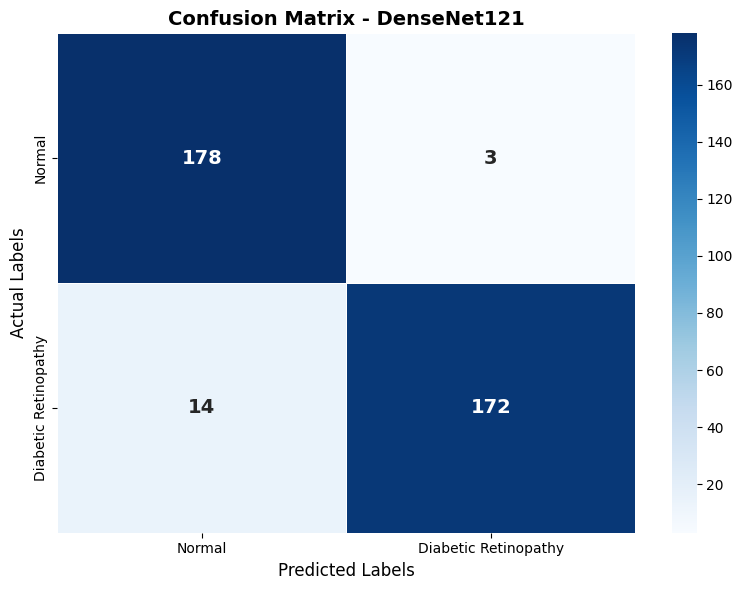

In [21]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Diabetic Retinopathy'],
            yticklabels=['Normal', 'Diabetic Retinopathy'],
            linewidths=0.5, annot_kws={'size': 14, 'weight':'bold'}
            )

ax.set_title('Confusion Matrix - DenseNet121', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Labels', fontsize=12)
ax.set_ylabel('Actual Labels', fontsize=12)
plt.tight_layout()
plt.show()

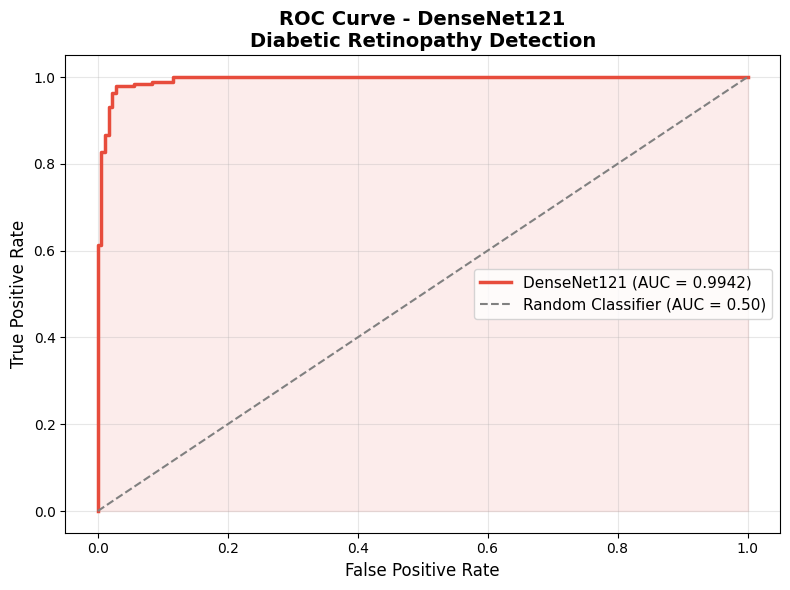

In [22]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
        label=f'DenseNet121 (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color ='gray', linewidth=1.5,
        linestyle='--', label='Random Classifier (AUC = 0.50)')

ax.fill_between(fpr, tpr, color='#e74c3c', alpha=0.1)

ax.set_title('ROC Curve - DenseNet121\nDiabetic Retinopathy Detection', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()